In [1]:
from pathlib import Path
from heap import pre_cleaning

In [2]:
#I guess we want to apply these scripts to the data structure as it is saved on the head node
#So we have the data pff file in a directory named after the corresponding day of observation as well das the housekeeping file named hk.pff
#Using the Gattini data for 20th October 2025 as an example, files are located in a directory name "20251020"
data_path="../test_data/20251020/pff/"
data_file=data_path+"start_2025-10-20T06:50:55Z.dp_ph1024.bpp_2.module_254.seqno_0.pff"
hk_file=data_path+"hk.pff"

data_path = Path(data_path).resolve()
if not data_path.exists():
    raise FileNotFoundError(f"Data directory not found: {data_path}")
# else:
#     print(data_path)

In [3]:
data_file

'../test_data/20251020/pff/start_2025-10-20T06:50:55Z.dp_ph1024.bpp_2.module_254.seqno_0.pff'

In [4]:
#Reading in the data pff file returning data and metadata
data,metadata=pre_cleaning.read_pff(data_file)

Data read in, number of events:  24330


In [5]:
#Removing images with package loss (where at leas one quabo is missing data) and return cut data and corresponding UTC timestamps
data,timestamps=pre_cleaning.cut_pkt_loss(data,metadata)

Number of Events with package loss:  42  ( 0.17 %)


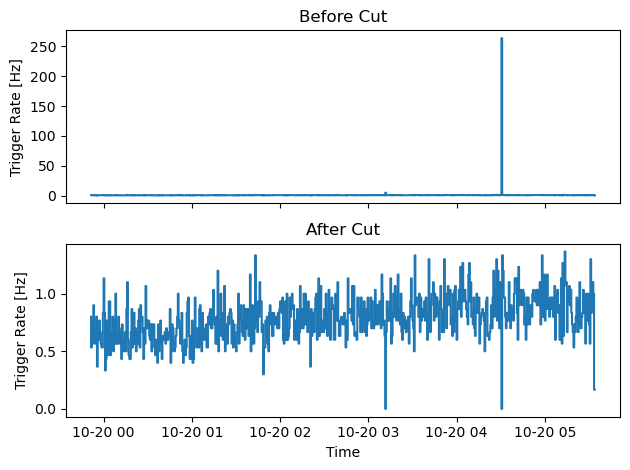

Rate spikes at:  DatetimeIndex(['2025-10-20 03:11:56.618505478-07:00', '2025-10-20 04:30:56.618505478-07:00'], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  8058  ( 33.18 %)


In [6]:
#Using timestamps to determine event rate (default 30 s bins) and cutting off bins above set threshold (default 2 Hz)
#Plotting Trigger Rate over time before and after spike cut
#Return spike cut data and timestamps
data_cut,timestamps_cut=pre_cleaning.spike_cut(data,timestamps,plotting=True)

In [7]:
#Reading in housekeeping file to get mount information for meridian flip cut later
hk=pre_cleaning.read_pff_hk(hk_file)

**Note:** observation runs are now stopped before the meridian flip and a new run started after it, so on current data there's normally nothing for `cut_meridian_flip()` to find mid-run. There should normally not be a reason to run this cut. This 20251020 Gattini file predates that change and still runs through the flip, which is why it's kept here to demonstrate the function.

Start of meridian flip (local time):  2025-10-20 04:30:40.480678082-07:00 , End:  2025-10-20 04:33:48.265557288-07:00
Duration of meridian flip cut:  187.78487920761108
Number of cut out events from meridian flip:  165  ( 1.02 %)


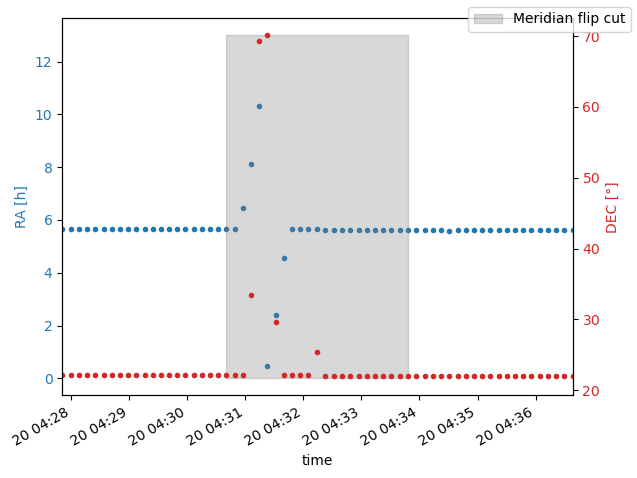

In [8]:
#Localizing meridian flip using the tracking parameter in the mount dictionary in the hk file (tracking off during flip)
#Removing a set timeframe after mount is tracking again to account for time needed to readjust the guiding (default 60 s)
#Plotting ra and dec values of mount around meridian flip (constant while tracking source), plot saved in data folder
#Returning data and timestamps after meridian flip cut and start and end timestamp of cut out data (can split data in pre and post meridian flip later)
data_cut_mflip,timestamp_cut_mflip,start_mflip,end_mplip=pre_cleaning.cut_meridian_flip(data_cut,timestamps_cut,hk,plotting=True,path=data_file)